In [31]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table, vstack
from dataclasses import replace
from scipy.ndimage import gaussian_filter1d
import importlib
import datetime as _dt
from astropy.io import fits
import os
from utils_lya_halo.stack import build_stacks

import run_config
import utils_lya_halo

from run_config import cfg, smoke
from utils_lya_halo import read_galaxy_fits, measure, plotting, analysis, stack, core
from utils_lya_halo.extract import build_run_table, build_bad_fiber_mask
from utils_lya_halo import PipelineConfig

from utils_lya_halo.stack import (convert_avg_fiber_bin, stack_spec_values, coadd_galaxies, rest_grid)

import warnings
from astropy.utils.exceptions import AstropyUserWarning

In [9]:
N = None
core_radius = 3.5 #Arcsec
catalog_path_sz = "catalogs/lya_halo_catalog_cuts/cosmos_web_specz_selection.ecsv"
field_sz = "COSMOS"
catalog_sz = "specz_val"

LYA_REST = 1215.67
cfg_specz = replace(cfg, 
    num_gal         = N,
    field           = field_sz,
    catalog         = catalog_sz,
    catalog_path    = catalog_path_sz,
    bins      = [0, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0],
    bin_mode  = "virial",
    mask_method     = "image",
    mask_percentile = 90,
    bg_inner_arcsec = 57.0,
    bg_outer_arcsec = 63.0,
    min_bg_fibers   = 25,
    smooth_bg       = True,
    smoothing_values = [200, 20, 300],
    fiber_combine_method   = "biweight",
    rest_delta      = 0.2,
    rest_wave_min   = 1000,
    rest_wave_max   = 1800,
    rest_density    = True,
    cut_radial_bin  = 5,
    min_good_wave   = 100,
    combine_wave_block = 32,
    line_window = [LYA_REST-4, LYA_REST+4],
    n_bootstrap = 1000)

def make_run_table(t, field="COSMOS", catalog="specz_val",
                   RA="RA", DEC="DEC", Z="z", MASS="logM"):
    """Run table in the pipeline's schema, carrying the columns the core
    hierarchical pass reads (continuum mags for EW/LAE, dust for later escape)."""
    rt = Table()
    rt["RA"]      = np.asarray(t[RA], float)
    rt["DEC"]     = np.asarray(t[DEC], float)
    rt["z"]       = np.asarray(t[Z], float)
    rt["MASS_50"] = np.asarray(t[MASS], float)

    # continuum mags (AB) for rest-frame EW + LAE classification.
    # carry all three; pick the band at call time (MAG_R/MAG_I for z~2-3).
    for col in ("MAG_G", "MAG_R", "MAG_I"):
        if col in t.colnames:
            rt[col] = np.asarray(t[col], float)

    # dust (nebular A_V) -> only needed if you switch escape back on later
    if "AV_neb" in t.colnames:
        rt["AV_neb"] = np.asarray(t["AV_neb"], float)
    # spec-z source / error, harmless to carry and useful for later splits
    for col in ("z_src", "sigma_z"):
        if col in t.colnames:
            rt[col] = np.asarray(t[col])

    rt["FIELD"]   = np.full(len(t), field)        # build_run_table filters on these
    rt["CATALOG"] = np.full(len(t), catalog)
    return rt

tab_sz  = Table.read(catalog_path_sz)
run_tbl = make_run_table(tab_sz, catalog=catalog_sz)

# Measurement Re-run

In [10]:
field = 'egs'

# --- RUN ---
# results = core.run_core_hierarchical(
#     Spec, Err, wave_obs, catalog_selection,
#     detect_snr=2.0,
#     red_offset=0.0,                          # window centered on systemic Lya
#     hw=4.0,                                  # half-width of the B window
#     n_sigma_emit=1.0, 
#     n_sigma_absorb=1.0, 
#     class_stat="B",                          # label off the constant-window S/N
#     cont_bounds=((1185,1205),(1225,1245)),   # tune the continuum sidebands here
#     cont_method="poly", cont_order=1,
#     flux_for_escape="mf",                    # 'A' | 'B' | 'mf'
#     ew_threshold=20.0, ew_flux="mf", mag_col="auto",
# )

# --- RE-RUN ---
# change one knob, keep the rest, write a new dated file (old one preserved)
# core.remeasure_core_fits(
#     f"outputs_core/6-19-26-core_extraction_{field}_MF.fits",
#     f"outputs_core/6-23-26-core_extraction_{field}_MF.fits",
#     detect_snr=2.0,
#     red_offset=0.0,
#     hw=4.0,
#     n_sigma_emit=1.0,
#     n_sigma_absorb=1.0,
#     class_stat="mf",
#     cont_bounds=((1185,1205),(1225,1245)),
#     cont_method="poly", cont_order=1,
#     flux_for_escape="mf",
#     ew_threshold=20.0, ew_flux="mf", mag_col="auto",
# )

# Reading in Data

In [38]:
catalog_a = Table.read('catalogs/lya_halo_catalog_cuts/cosmos_web_specz_selection.ecsv', format='ascii')

prod_specz1 = core.read_core_fits("outputs_core/6-27-26-core_extraction_cosmosweb_specz.fits")
prod_specz2 = core.read_core_fits("outputs_core/6-27-26-core_extraction_cosmosweb_specz2.fits")

prod_specz = stack.concat_core_prods(prod_specz1, prod_specz2)
print(f"pooled {prod_specz['n_per_input']} -> {len(prod_specz['core_spec'])} galaxies")

stack_specz = core.build_core_stacks(cfg_specz, prod_specz, output="flux")

pooled [969, 581] -> 1550 galaxies


# Compare Stacks

In [39]:
print(f"Number of Gaussian measurements: {np.sum(~np.isnan(prod_specz['results']['v_offset']))}")

Number of Gaussian measurements: 491


In [40]:
stacka_all = core.build_core_stacks(cfg_specz, prod_specz, output="flux")

# TYPES OF GALAXIES
maska_lae = (prod_specz['results']['label'] == 'LAE')
maska_em = (prod_specz['results']['label'] == 'emitter')
maska_abs = (prod_specz['results']['label'] == 'absorber')
maska_null = (prod_specz['results']['label'] == 'null')

print(np.sum(mask_lae), np.sum(mask_em), np.sum(mask_abs), np.sum(mask_null))

stacka_lae = core.build_core_stacks(cfg_specz, prod_specz, mask=maska_lae, output="flux")
stacka_null = core.build_core_stacks(cfg_specz, prod_specz, mask=maska_null, output="flux")
stacka_em = core.build_core_stacks(cfg_specz, prod_specz, mask=maska_em, output="flux")
stacka_abs = core.build_core_stacks(cfg_specz, prod_specz, mask=maska_abs, output="flux")

# # OTHER-SELECTIONS
# mask_blue = (prod_specz['results']['v_offset'] < 0)
# mask_red = (prod_specz['results']['v_offset'] > 0)
# mask_lmass = (prod_specz['catalog']['MASS_50'] < np.nanmedian(prod_specz['catalog']['MASS_50']))
# mask_hmass = (prod_specz['catalog']['MASS_50'] > np.nanmedian(prod_specz['catalog']['MASS_50']))
# mask_lz = (prod_specz['catalog']['z'] < ((3.5 + 1.9)/2))
# mask_hz = (prod_specz['catalog']['z'] > ((3.5 + 1.9)/2))

# print(np.sum(mask_blue), np.sum(mask_red), np.sum(mask_lmass), np.sum(mask_hmass), np.sum(mask_lz), np.sum(mask_hz))

# stacka_blue = core.build_core_stacks(cfg_specz, prod_specz, mask=mask_blue, output="flux")
# stacka_red = core.build_core_stacks(cfg_specz, prod_specz, mask=mask_red, output="flux")
# stacka_lmass = core.build_core_stacks(cfg_specz, prod_specz, mask=mask_lmass, output="flux")
# stacka_hmass = core.build_core_stacks(cfg_specz, prod_specz, mask=mask_hmass, output="flux")
# stacka_lz = core.build_core_stacks(cfg_specz, prod_specz, mask=mask_lz, output="flux")
# stacka_hz = core.build_core_stacks(replace(cfg_specz,rest_wave_min=900,rest_wave_max=1500), prod_specz, mask=mask_hz, output="flux")

186 332 71 380


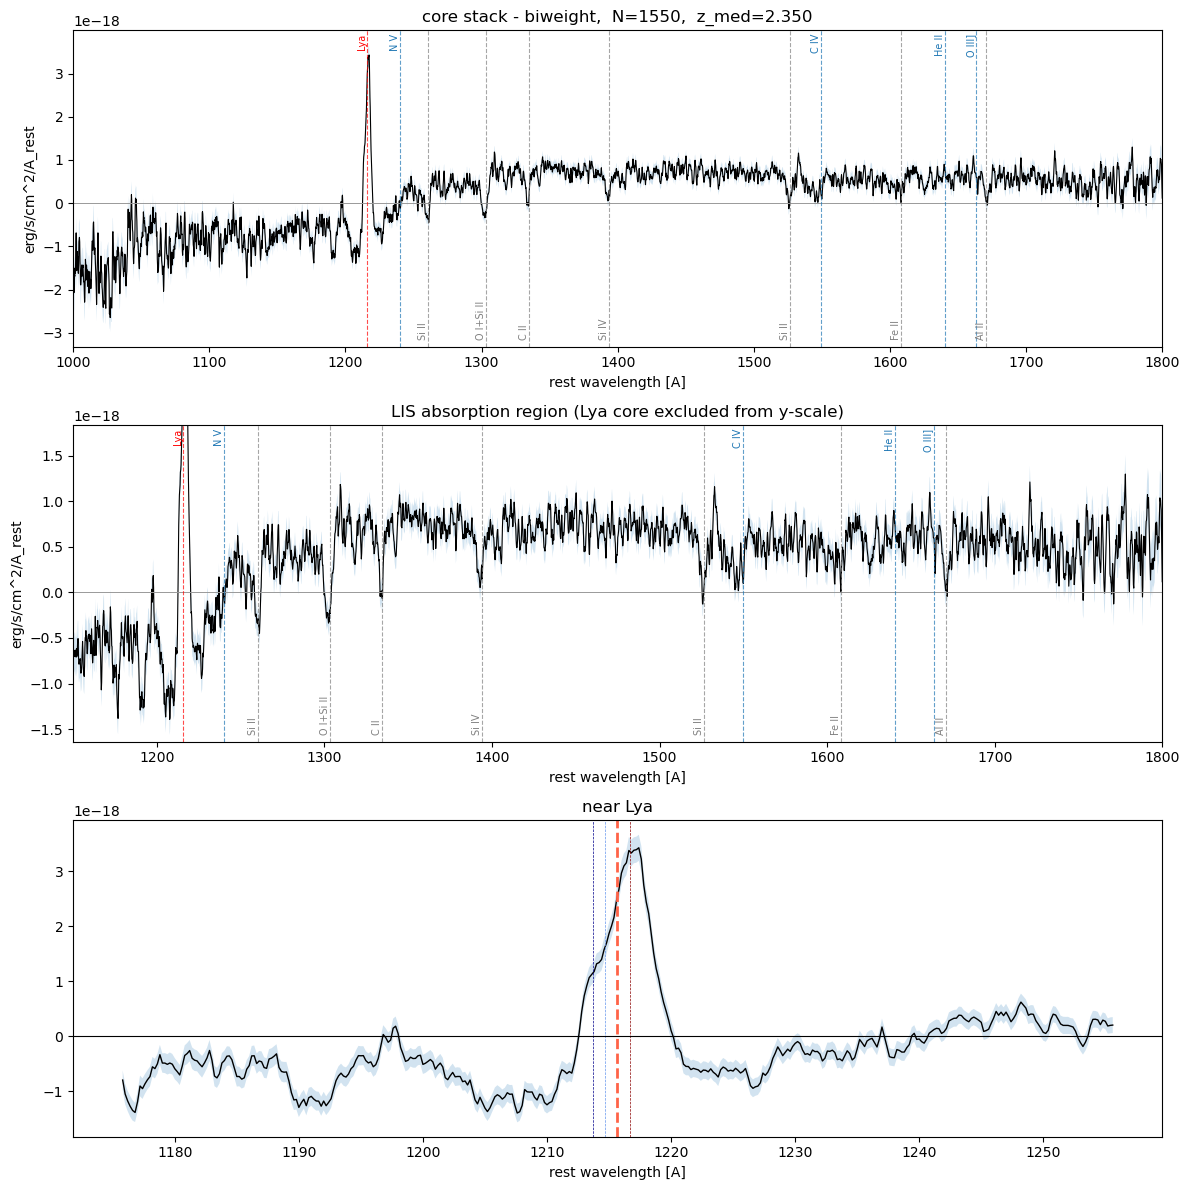

In [28]:
plotting.plot_core_stack(stacka_all, method="biweight")

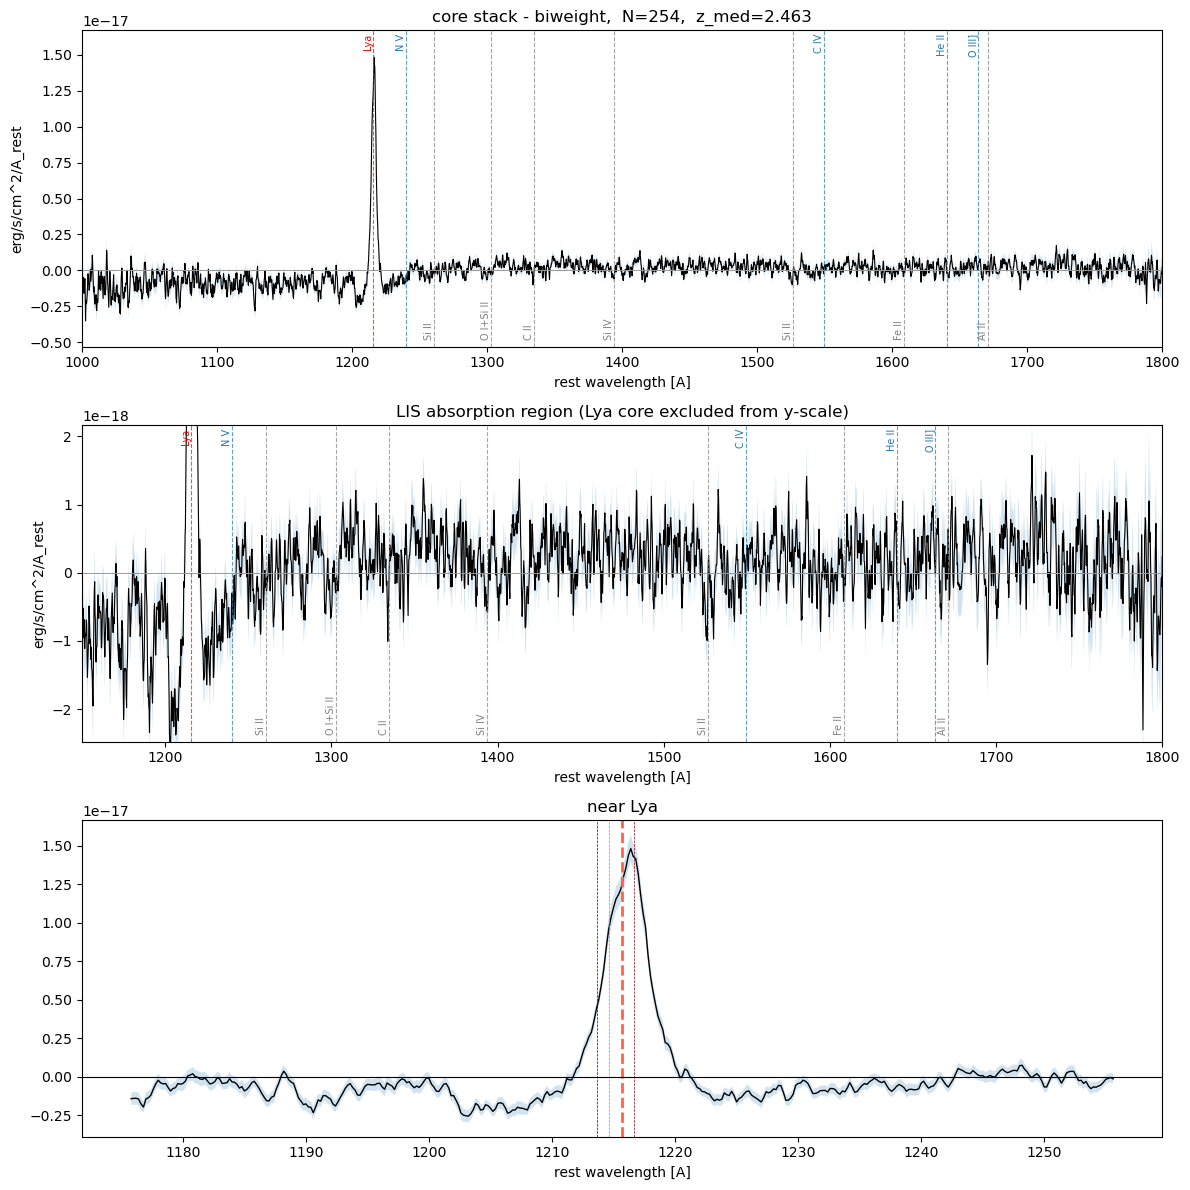

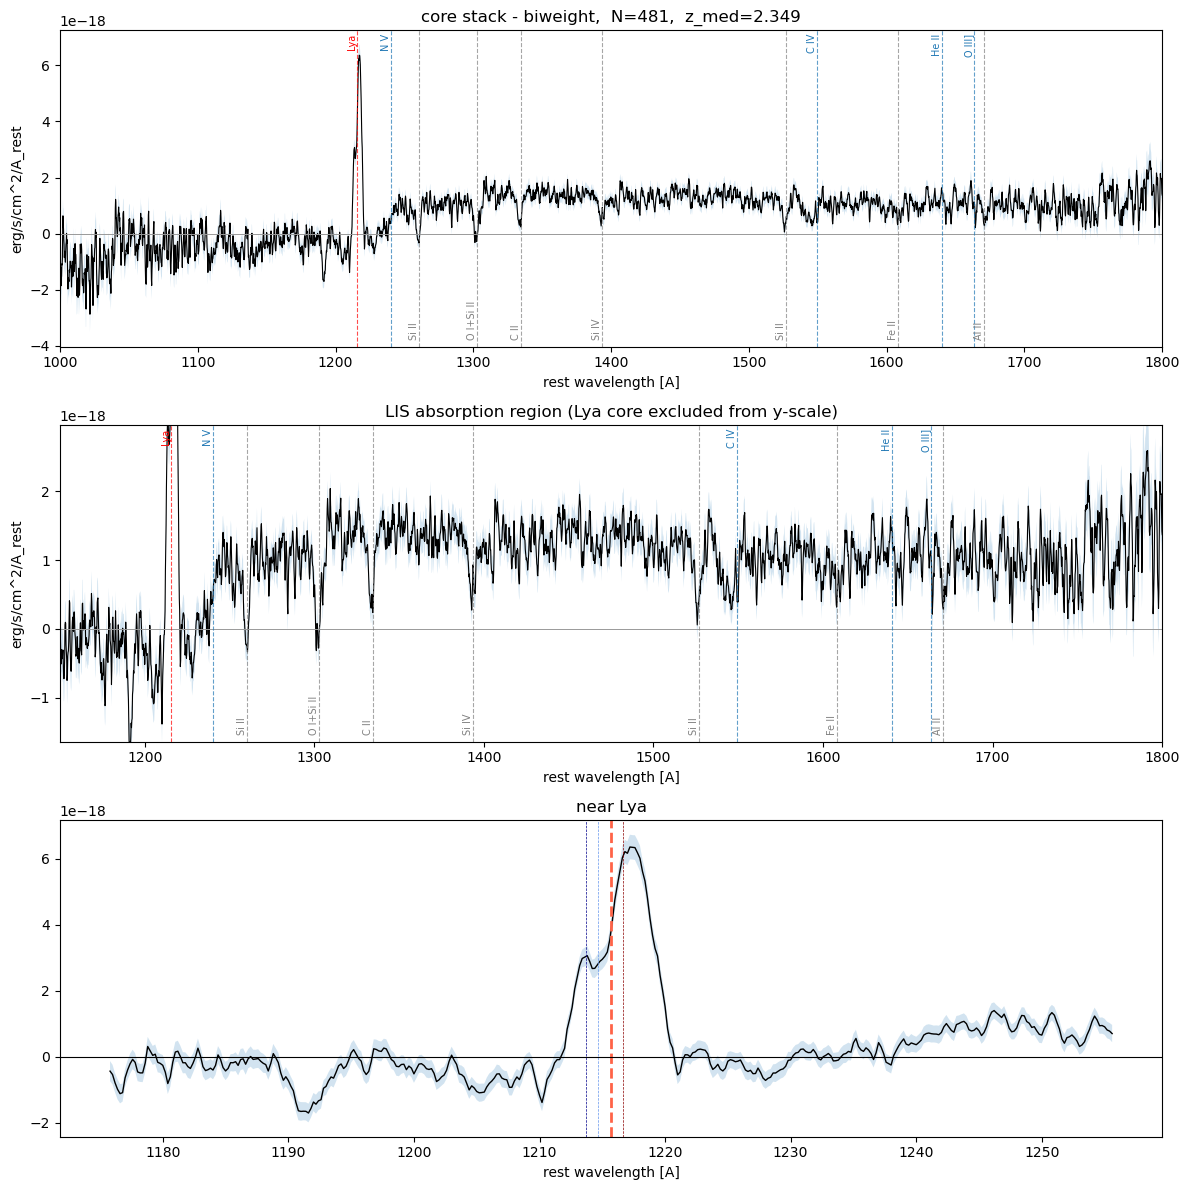

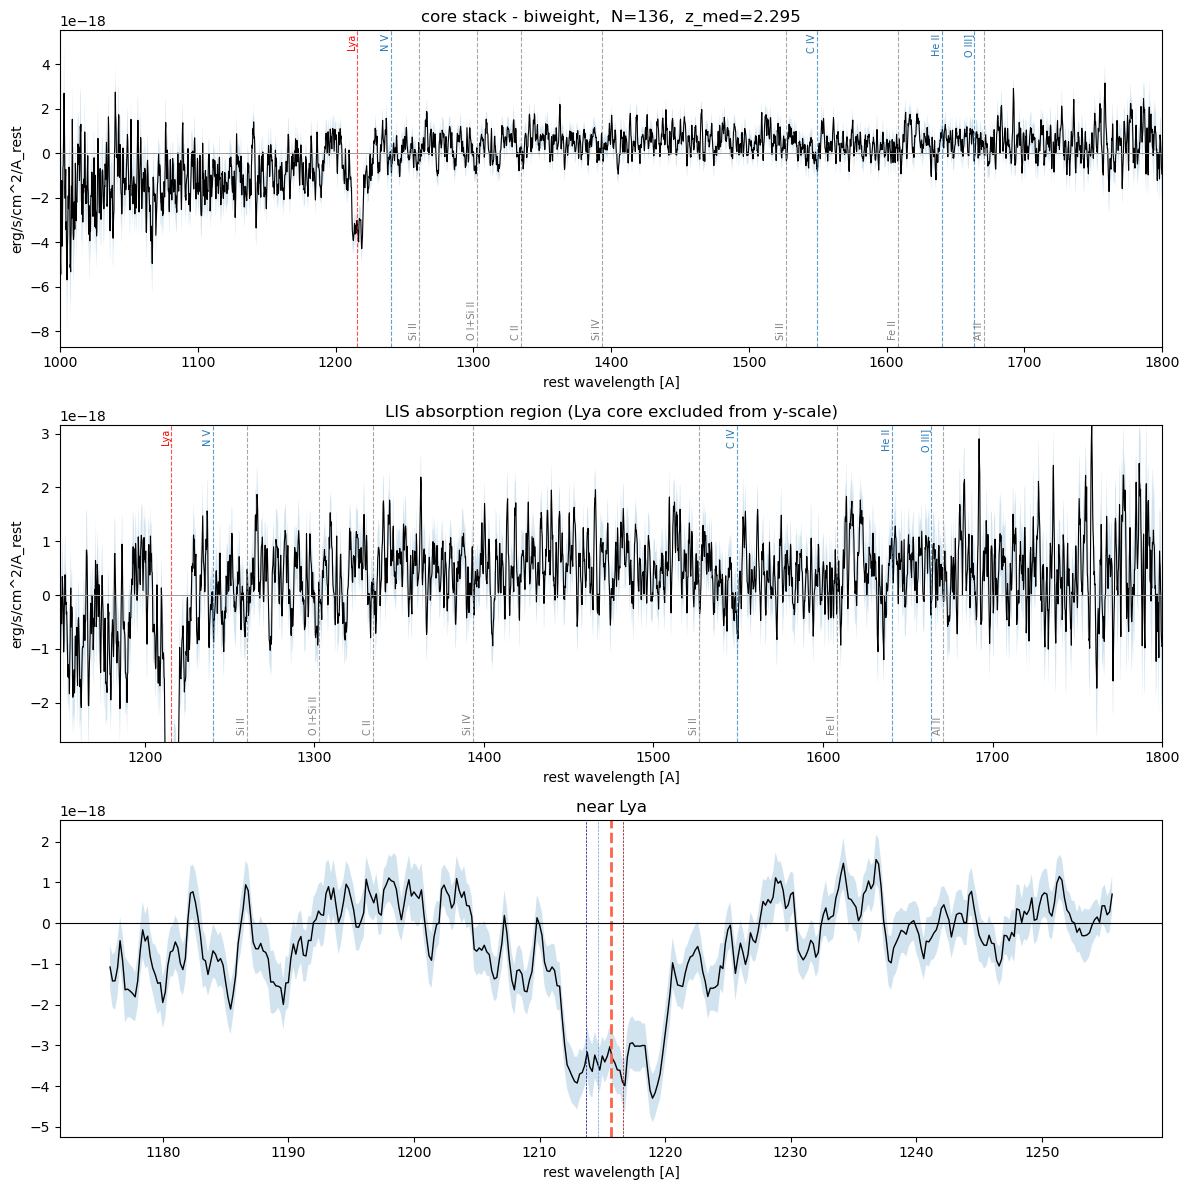

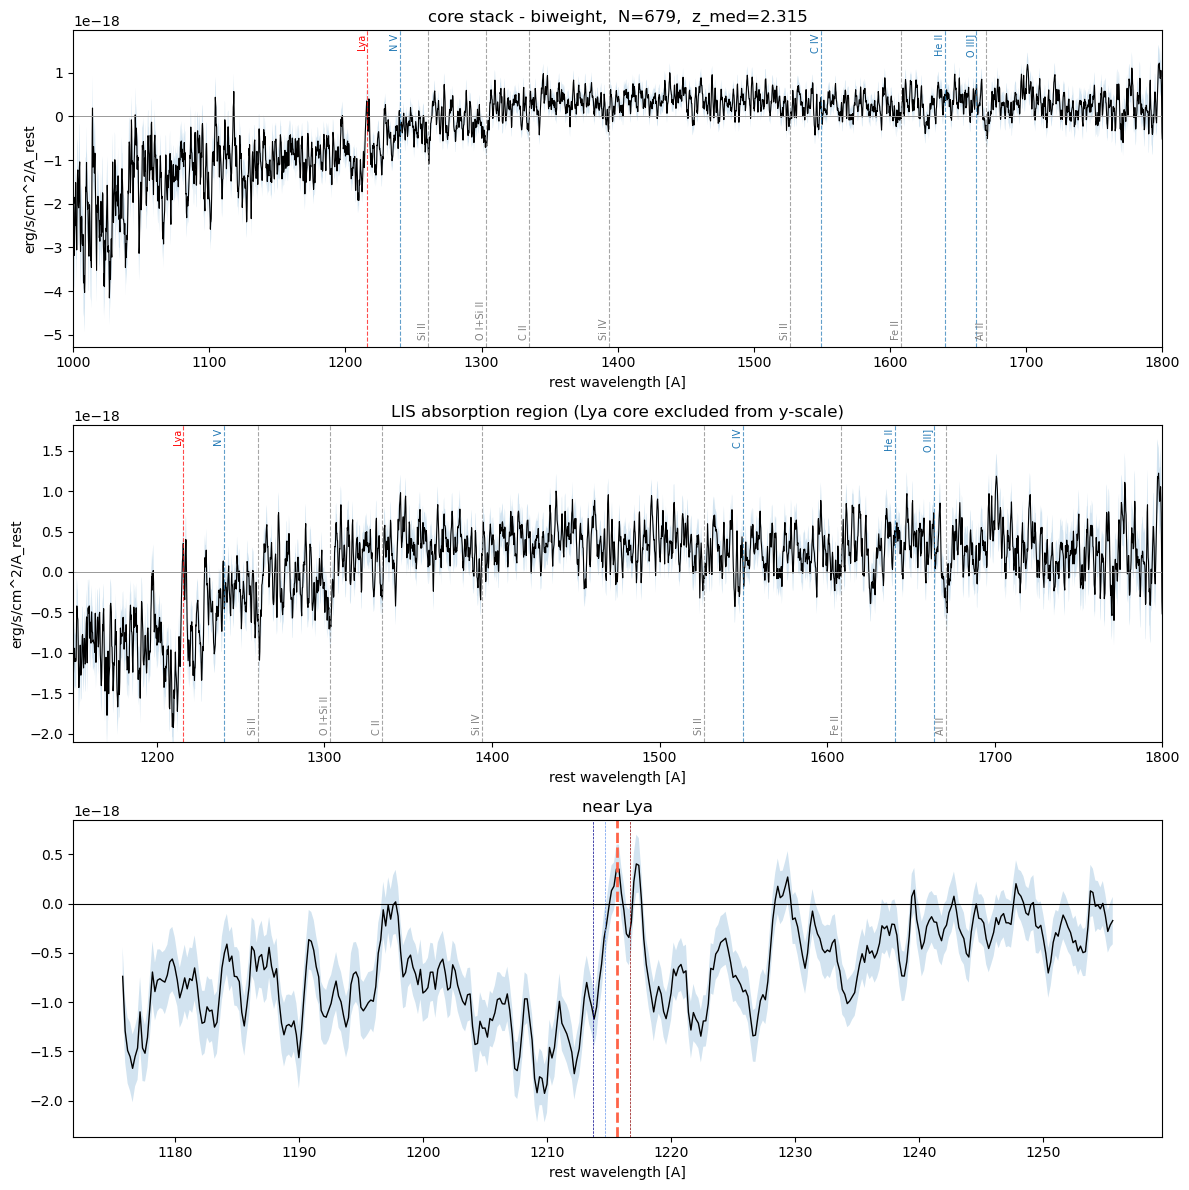

In [29]:
plotting.plot_core_stack(stacka_lae, method="biweight")
plotting.plot_core_stack(stacka_em, method="biweight")
plotting.plot_core_stack(stacka_abs, method="biweight")
plotting.plot_core_stack(stacka_null, method="biweight")

In [43]:
catalog_all = Table.read('catalogs/lya_halo_catalog_cuts/cosmos_web_specz_234.ecsv', format='ascii')
catalog_all[:5]

RA,DEC,z,logM,z_src,sigma_z,AV_neb,MAG_G,MAG_R,FIELD,CATALOG
float64,float64,float64,float64,str4,float64,float64,float64,float64,str6,str7
149.88425326654445,2.1669077447261795,2.9891,8.90079,spec,0.0019959307982324224,0.9199999999999999,25.00608022517574,24.752333843314176,COSMOS,lyahalo
149.88129685668642,2.1860371774394163,1.944,9.6789,spec,0.0014730190443950394,0.9199999999999999,24.01167578801804,23.743823257208827,COSMOS,lyahalo
149.87646723296672,2.19702133875138,2.2041,10.78077,spec,0.0016031590761365984,1.8399999999999999,24.50487343479503,24.08022741600586,COSMOS,lyahalo
149.8926663257104,2.19179395329904,2.275,8.65299,spec,0.001638633617660922,0.0,25.10910622103033,25.197529410696955,COSMOS,lyahalo
149.87516683041403,2.201991157574644,1.9735,9.65122,spec,0.0014877792556075577,0.9199999999999999,24.0857954468904,23.901842575206842,COSMOS,lyahalo


(array([ 1.,  1.,  0.,  1.,  0.,  0.,  1.,  0.,  2.,  1.,  0.,  1.,  1.,
         0.,  1.,  0.,  1.,  3.,  1.,  2.,  1.,  1.,  4.,  3.,  3.,  2.,
        14.,  8.,  9.,  7.,  8.,  7., 12., 17., 13., 15., 22., 18., 17.,
        27., 36., 37., 32., 28., 29., 35., 32., 49., 34., 33., 42., 35.,
        52., 41., 39., 42., 53., 42., 45., 37., 35., 43., 32., 34., 32.,
        26., 33., 24., 27., 24., 17., 15., 20., 14., 18.,  7., 13.,  8.,
        16.,  7., 13.,  9.,  9., 13., 11.,  2., 12.,  5., 11.,  4.,  5.,
         4.,  3.,  2.,  0.,  0.,  0.,  0.,  1.,  1.]),
 array([ 7.19503 ,  7.238661,  7.282292,  7.325923,  7.369554,  7.413185,
         7.456816,  7.500447,  7.544078,  7.587709,  7.63134 ,  7.674971,
         7.718602,  7.762233,  7.805864,  7.849495,  7.893126,  7.936757,
         7.980388,  8.024019,  8.06765 ,  8.111281,  8.154912,  8.198543,
         8.242174,  8.285805,  8.329436,  8.373067,  8.416698,  8.460329,
         8.50396 ,  8.547591,  8.591222,  8.634853,  8.678484,  

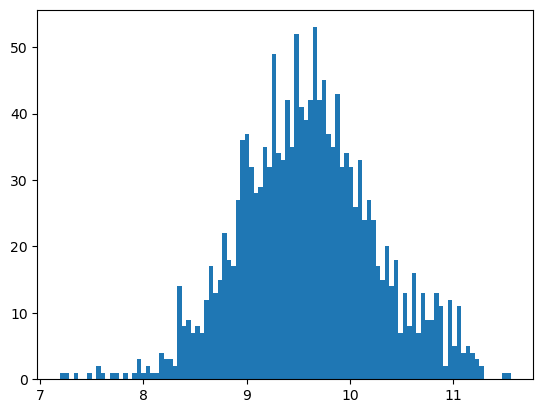

In [44]:
plt.hist(catalog_all['logM'], 100)

# Halo Spec

In [53]:
cfg_specz_all = replace(cfg, 
    field           = "COSMOS",
    catalog         = "lyahalo",
    catalog_path    = "catalogs/lya_halo_catalog_cuts/cosmos_web_specz_234.ecsv",
    bins      = [0, 10, 20, 30, 50, 80, 130, 250, 500, 1000],
    bin_mode  = "kpc",
    mask_method     = "image",
    mask_percentile = 90,
    bg_inner_arcsec = 57.0,
    bg_outer_arcsec = 63.0,
    min_bg_fibers   = 25,
    smooth_bg       = True,
    smoothing_values = [200, 20, 300],
    fiber_combine_method   = "biweight",
    mass_col = "logM",
    z_col    = "z",
    rest_delta      = 0.2,
    rest_wave_min   = 1100,
    rest_wave_max   = 1700,
    rest_density    = True,
    cut_radial_bin  = 5,
    min_good_wave   = 100,
    combine_wave_block = 32,
    line_window = [LYA_REST-4, LYA_REST+4],
    n_bootstrap = 500)

prod_specz_all = read_galaxy_fits('./outputs/galaxy_cat4aaf71_b9_f0fd45_COSMOS_lyahalo_kpc_biweight_image_bg57-63.fits')

print("ngal, nrad, nwave:", prod_specz_all.ngal, prod_specz_all.nrad, prod_specz_all.nwave)   # expect 5, 6, 1036
print("R_EDGES:", prod_specz_all.r_edges)                   # your renamed attribute
print("background present?", prod_specz_all.background is not None)
print("header FIELD/NGAL:", prod_specz_all.header["FIELD"], prod_specz_all.header["NGAL"])

# sanity: galaxy axis lines up with catalog rows
assert len(prod_specz_all.catalog) == prod_specz_all.ngal

print(np.round(np.median(prod_specz_all.nfib, axis=0), 3).astype(int))

stacks_specz_all = build_stacks(cfg_specz_all, prod_specz_all, keep_cube=True)

ngal, nrad, nwave: 1548 9 1036
R_EDGES: [   0.   10.   20.   30.   50.   80.  130.  250.  500. 1000.]
background present? True
header FIELD/NGAL: COSMOS 1548
[   10    30    50   161   393  1045  4583 19144 75548]


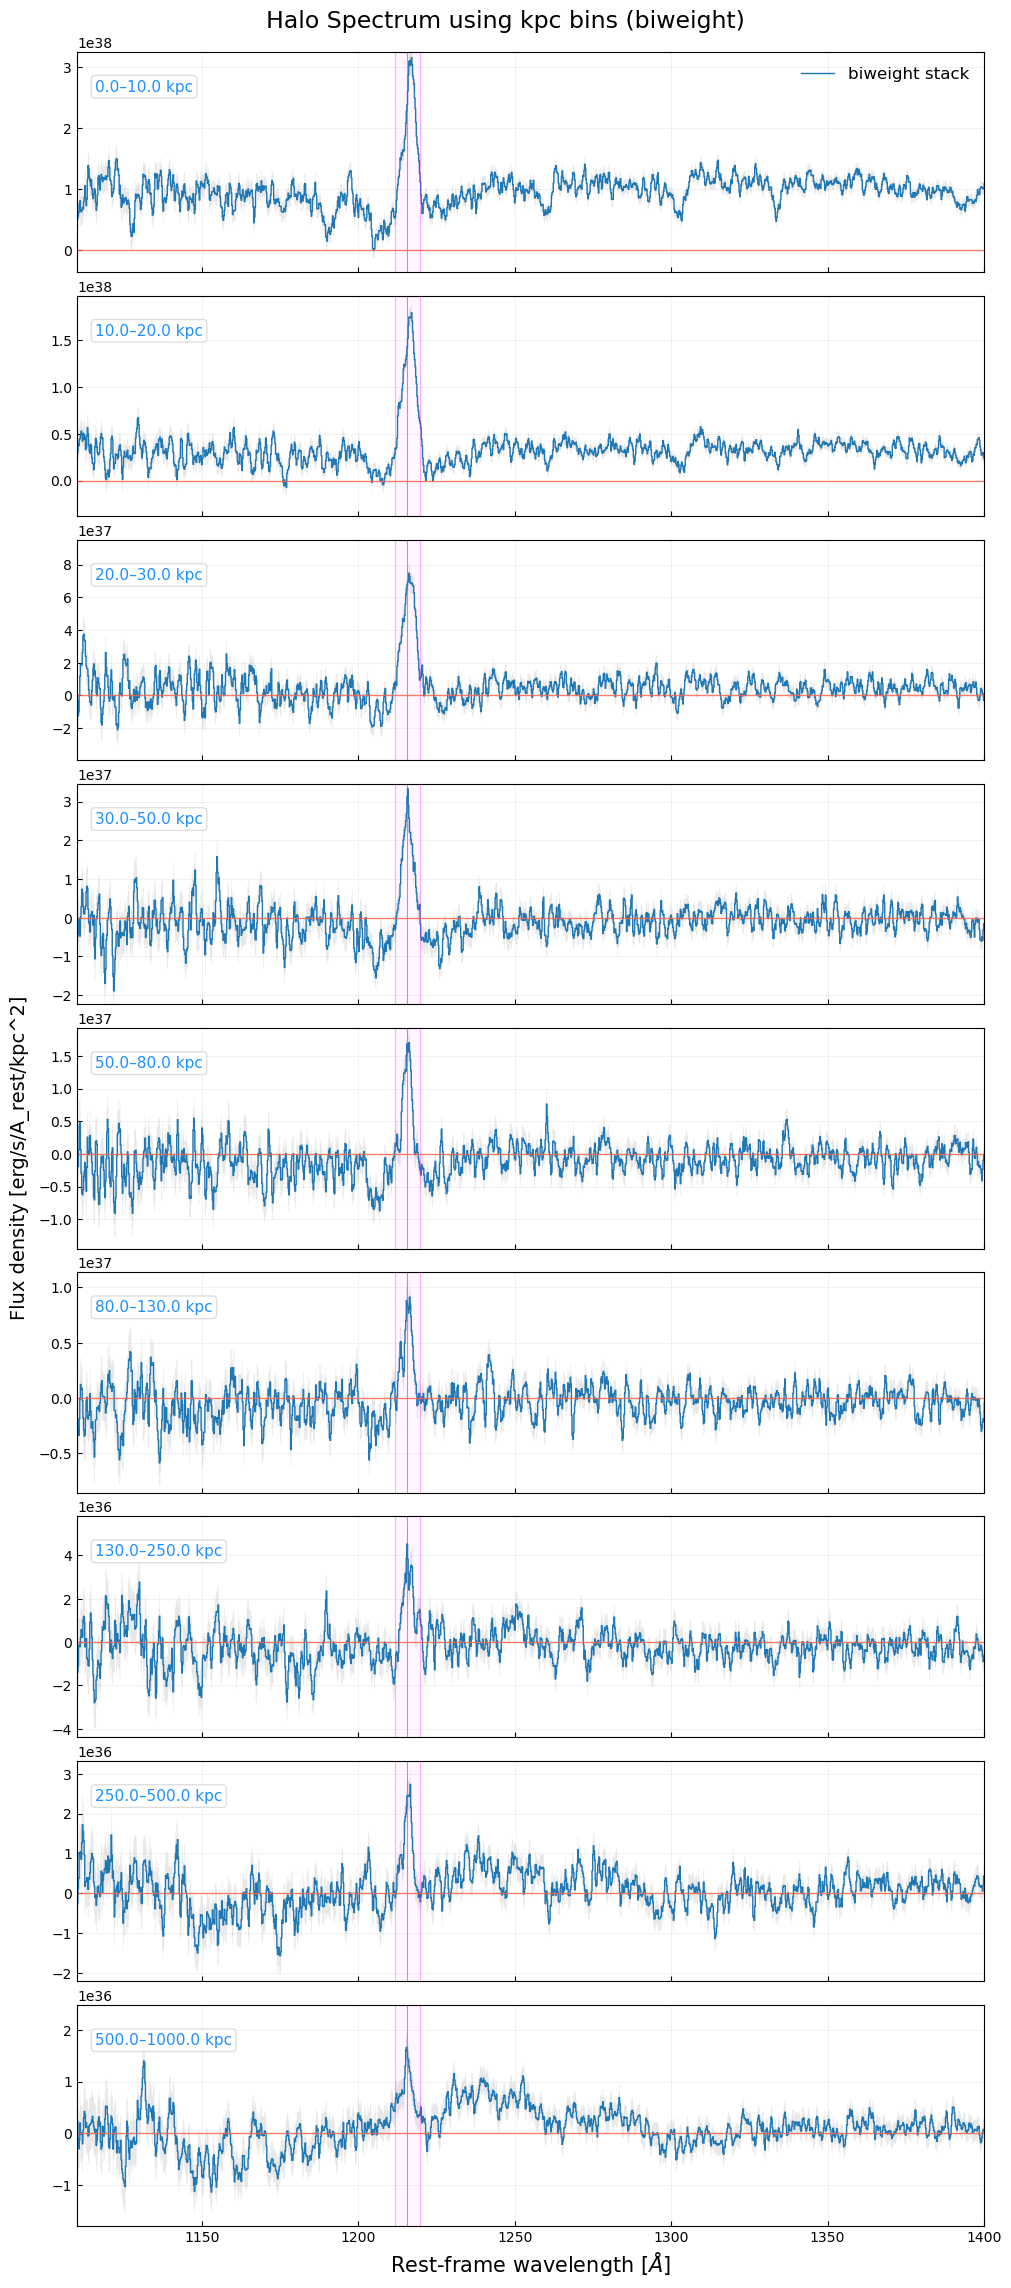

(<Figure size 1000x2250 with 9 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >,
        <Axes: xlabel='Rest-frame wavelength [$\\AA$]'>], dtype=object))

In [52]:
plotting.plot_stack_panels(stacks_specz_all,
    method="biweight",
    distance_type="kpc",
    title=None,
    xlim=(1110, 1400),
    lya_window=4,
    figsize_width=10,
    panel_height=2.5,
    show_err=True,
    smooth=None,
    savepath=None,
    dpi=300)

In [55]:
# Stage 3: run everything
boot = analysis.run_measurement_suite(cfg_specz_all, stacks_specz_all)

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]


line moments (fiducial stack, no bootstrap):
  0-10: v=+203.6  σ=391.3  skew=-0.337
  10-20: v=+125.3  σ=431.9  skew=-0.224
  20-30: v=+102.1  σ=432.7  skew=-0.223
  30-50: v=+43.0  σ=392.2  skew=+0.122
  50-80: v=-25.7  σ=336.8  skew=-0.331
  80-130: v=+0.3  σ=369.2  skew=-0.138
  130-250: v=+119.0  σ=388.5  skew=+0.306
  250-500: v=-2.7  σ=296.6  skew=-0.625
  500-1000: v=-96.2  σ=377.1  skew=-0.412


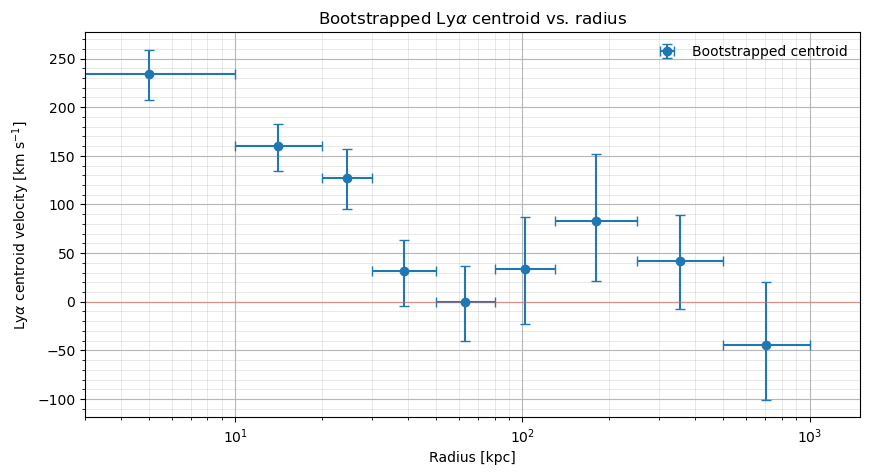

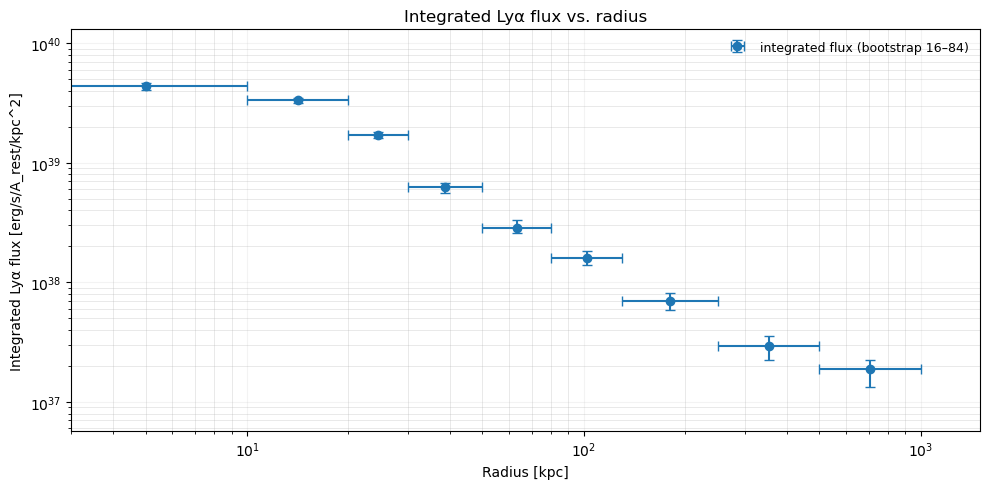

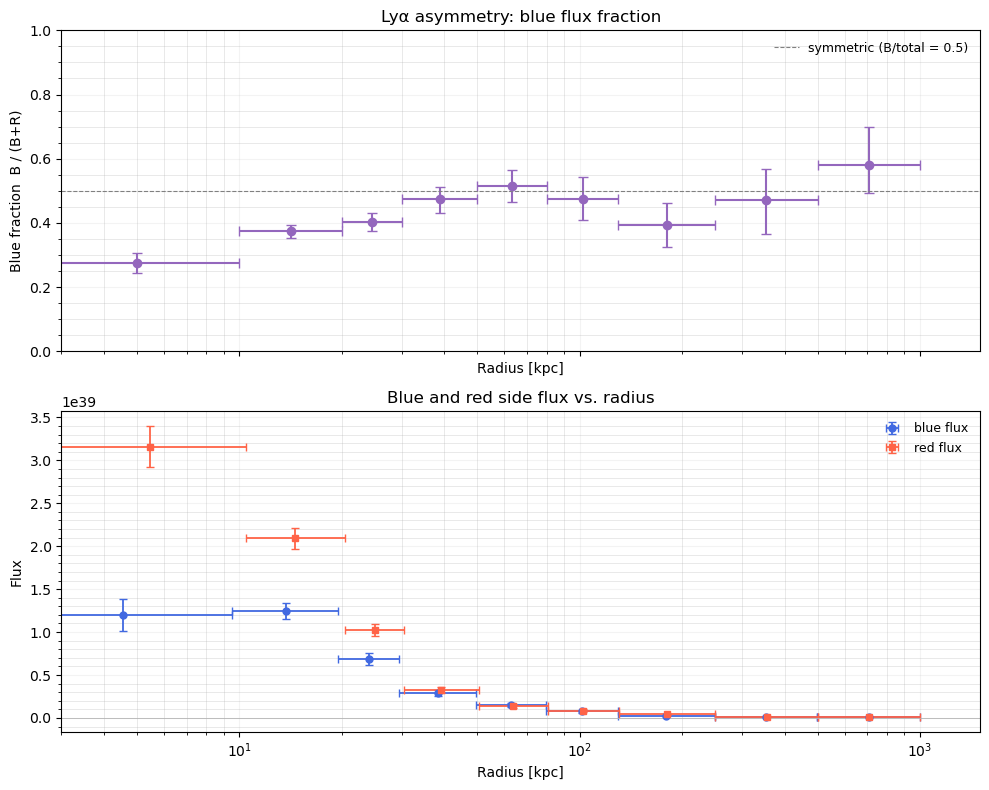

(<Figure size 1000x800 with 2 Axes>,
 (<Axes: title={'center': 'Lyα asymmetry: blue flux fraction'}, xlabel='Radius [kpc]', ylabel='Blue fraction  B / (B+R)'>,
  <Axes: title={'center': 'Blue and red side flux vs. radius'}, xlabel='Radius [kpc]', ylabel='Flux'>))

In [58]:
xlims = (3, 1500)

#Radial profiles
analysis.plot_centroid_profile(boot, stacks_specz_all,
    ylims=None,
    xlims=xlims,
    figsize=(10, 5))
analysis.plot_flux_profile(boot, stacks_specz_all,
    ylims=None,
    xlims=xlims,
    figsize=(10, 5))
analysis.plot_asymmetry_profile(boot, stacks_specz_all,
    xlims=xlims,
    figsize=(10, 8))